In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

# custom functions
import sc_toolbox as sct

Running Scanpy 1.8.2, on 2024-09-22 17:49.


In [2]:
## path variables
adata_dir = '/mnt/smb2/Niklas/GLPG_data_temp/240731_GLPG_annotated.h5ad'
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/'

In [3]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig1/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_dir)

In [5]:
## have a look at the adata object: 442k cells x 25194 genes
adata

AnnData object with n_obs × n_vars = 442439 × 24500
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2', 'cell_type'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'GLPG_annotation_colors', 'cell_type_colors', 'condition_colors', 'hvg', 'louvain_1_colors', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'treatment_time_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivities', 'distances'

### Add metadata

In [6]:
metadata = pd.read_csv(data_dir + '20201117_GLPG_metadata.csv', sep=',', index_col = 'identifier')
metadata.head(5)

,group,time_point,ChromiumBatch,LibraryPrepBatch,SeqBatch,ashcroft_score,body_weight_d0,body_weight_d1,body_weight_d2,body_weight_d3,...,body_weight_d17,body_weight_d18,body_weight_d19,body_weight_d20,body_weight_d21,body_weight_min,body_weight_max,delta_max_body_weight,delta_body_weight_d7_10,delta_body_weight_d14_d21
identifier,,,,,,,,,,,,,,,,,,,,,
d10BLM_Combo39,BLM_Combo,d10,run 1,Lib1,Seq1,2.2500,23.5,22.3,22.4,22.9,...,NaN,NaN,NaN,NaN,NaN,21.0,23.5,-2.5,-2.5,NaN
d10BLM_Combo41,BLM_Combo,d10,run 3,Lib1,Seq3,2.5625,23.8,22.4,23.4,23.7,...,NaN,NaN,NaN,NaN,NaN,22.4,24.0,-1.4,-0.5,NaN
d10BLM_Combo42,BLM_Combo,d10,run 2,Lib1,Seq2,2.6875,24.6,24.1,24.0,24.4,...,NaN,NaN,NaN,NaN,NaN,22.0,24.6,-2.6,-1.4,NaN
d10BLM_Combo43,BLM_Combo,d10,run 4,Lib3,Seq4,1.7500,25.8,25.3,24.8,25.1,...,NaN,NaN,NaN,NaN,NaN,23.0,25.8,-2.8,-2.8,NaN
d10BLM_Combo44,BLM_Combo,d10,run 5,Lib3,Seq5,1.5625,23.5,23.0,22.9,22.9,...,NaN,NaN,NaN,NaN,NaN,22.9,24.5,-0.6,0.2,NaN


In [7]:
del metadata['time_point']

In [8]:
## convert metadata df to dict
metadata_dict = metadata.to_dict(orient='index')

In [9]:
for key, values in metadata_dict.items():
    #print(key)
    mask = adata.obs['sample_name'] == key
    for col, val in values.items():
        #print(col)
        adata.obs.loc[mask, col] = val

/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'group' as categorical
/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'ChromiumBatch' as categorical
/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_cate

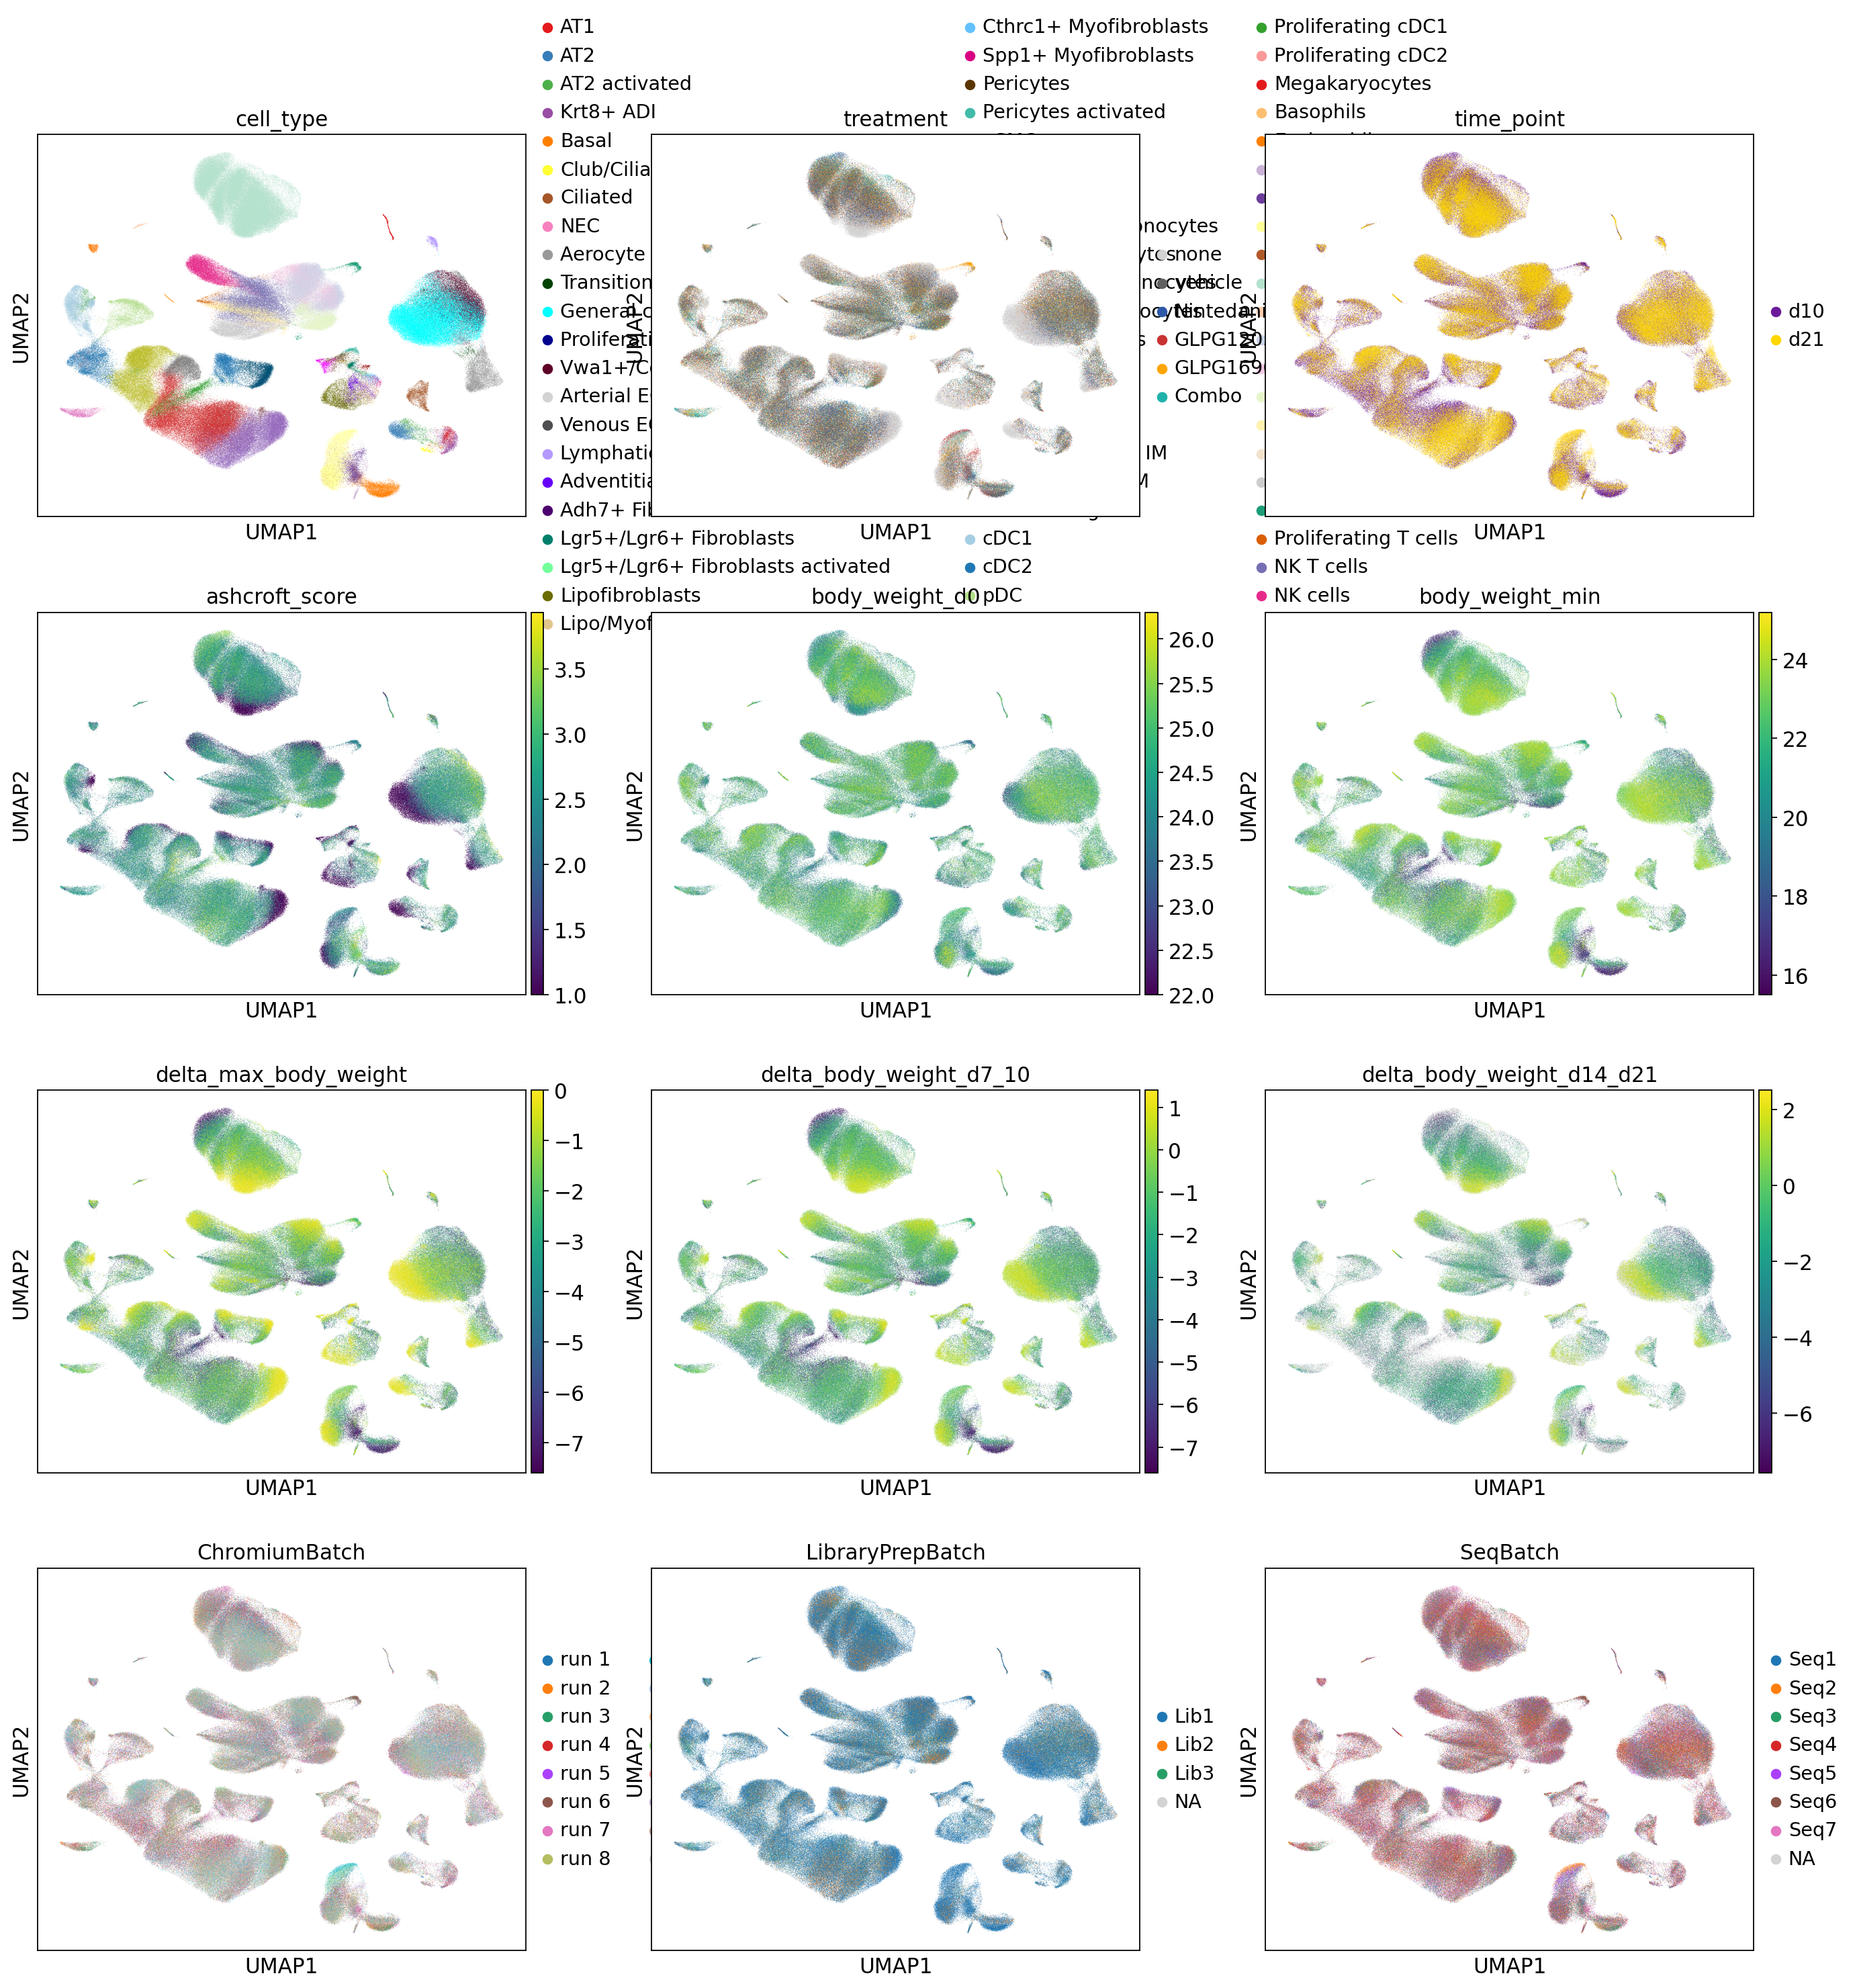

In [10]:
sc.pl.umap(adata, color = ['cell_type',
                           'treatment',
                           'time_point',
                           'ashcroft_score',
                           'body_weight_d0',
                           'body_weight_min',
                           'delta_max_body_weight',
                           'delta_body_weight_d7_10',
                           'delta_body_weight_d14_d21',
                           'ChromiumBatch',
                           'LibraryPrepBatch',
                           'SeqBatch'
                          ],
          ncols = 3)

In [11]:
adata.write('/mnt/smb2/Niklas/GLPG_data_temp/240811_GLPG_annotated.h5ad')